In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sys 

In [19]:
df = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
print(df.head(10))
print(df.columns)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7          8    15656148    Obinna          376   Germany  Female   29   
8          9    15792365        He          501    France    Male   44   
9         10    15592389        H?          684    France    Male   27   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0       

In [20]:
df.dtypes

RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

All data types appear to be correct for now. I will take decisions later about how to process the categorical variables.

I am also renaming the columns: Card Type, Point Earned, and Satisfaction Score to match the formatting of the rest of the double word columns

In [21]:
df.rename(columns={'Card Type': 'CardType'}, inplace=True)
df.rename(columns={'Point Earned': 'PointEarned'}, inplace=True)
df.rename(columns={'Satisfaction Score': 'SatisfactionScore'}, inplace=True)
df = df.drop(columns=['RowNumber'])

checking the min/max values of numerical variables to set the estimated_ranges

In [22]:
df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'PointEarned', 'SatisfactionScore']].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,PointEarned,SatisfactionScore
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881,606.515100,3.013800
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818,225.924839,1.405919
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000,119.000000,1.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000,410.000000,2.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000,605.000000,3.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500,801.000000,4.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000,1000.000000,5.000000


In [23]:
expected_schema = {
    'CustomerId': 'int64',
    'Surname': 'object',
    'CreditScore': 'int64',
    'Geography': 'object',
    'Gender': 'object',
    'Age': 'int64',
    'Tenure': 'int64',
    'Balance': 'float64',
    'NumOfProducts': 'int64',
    'HasCrCard': 'int64',
    'IsActiveMember': 'int64',
    'EstimatedSalary': 'float64',
    'Exited': 'int64',
    'Complain': 'int64',
    'SatisfactionScore': 'int64',
    'CardType': 'object',
    'PointEarned': 'int64'
}

expected_ranges = {
    'CreditScore': (350, 850), 
    'Age': (0, 100), 
    'Tenure': (0, 10), 
    'Balance': (0, 260000), 
    'NumOfProducts': (1, 4), 
    'EstimatedSalary': (0, 200000), 
    'PointEarned': (0, 1000)
}

In [24]:
sys.path.append('../src/data')

from data_validation import validate_schema, validate_nulls, validate_ranges, run_data_validation


validate_schema(df, expected_schema)
validate_nulls(df, None)
validate_ranges(df, expected_ranges)

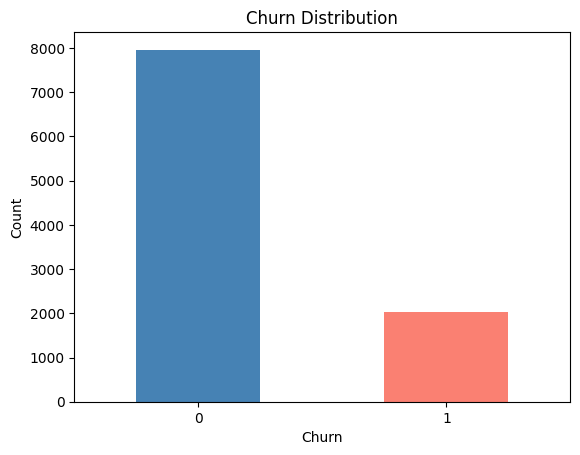

In [25]:
df['Exited'].value_counts().sort_index().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0) 
plt.show()

dataset is imbalanced, need to explore techniques like SMOTE or class-weight to try to balance it

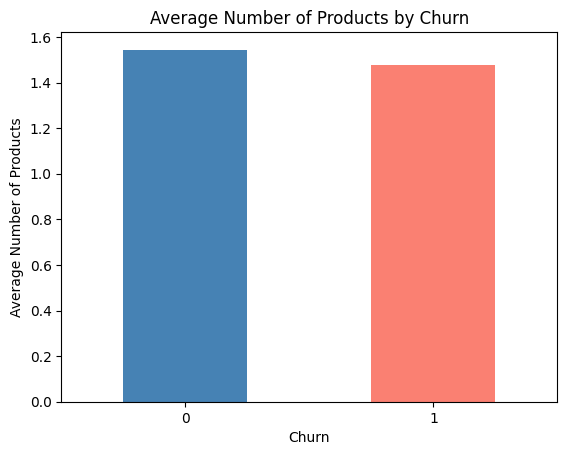

In [27]:
df.groupby('Exited')['NumOfProducts'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Average Number of Products by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Number of Products')
plt.xticks(rotation=0)
plt.show()

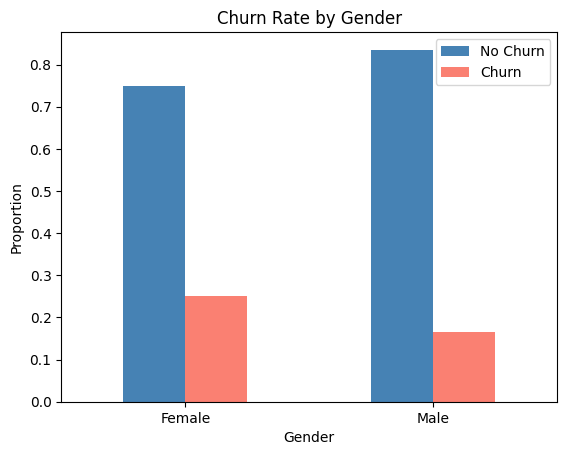

In [36]:
df.groupby('Gender')['Exited'].value_counts(normalize=True).unstack().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.show()

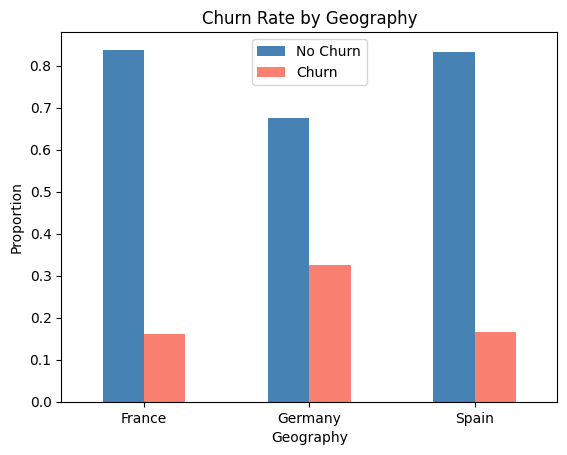

In [37]:
df.groupby('Geography')['Exited'].value_counts(normalize=True).unstack().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.show()

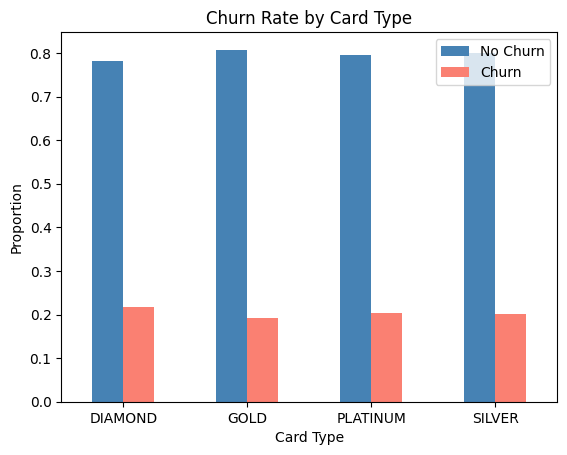

In [38]:
df.groupby('CardType')['Exited'].value_counts(normalize=True).unstack().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Rate by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.show()

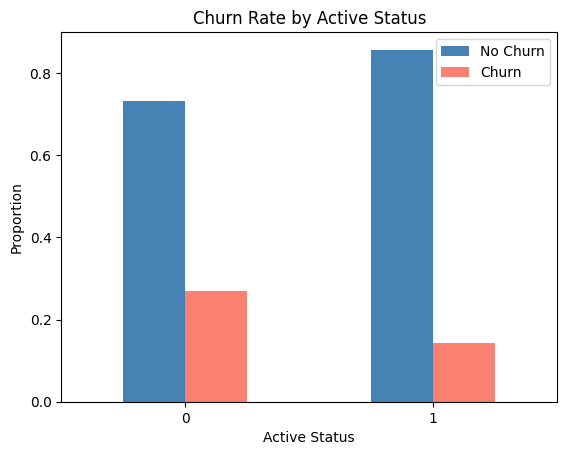

In [40]:
df.groupby('IsActiveMember')['Exited'].value_counts(normalize=True).unstack().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Rate by Active Status')
plt.xlabel('Active Status')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.show()

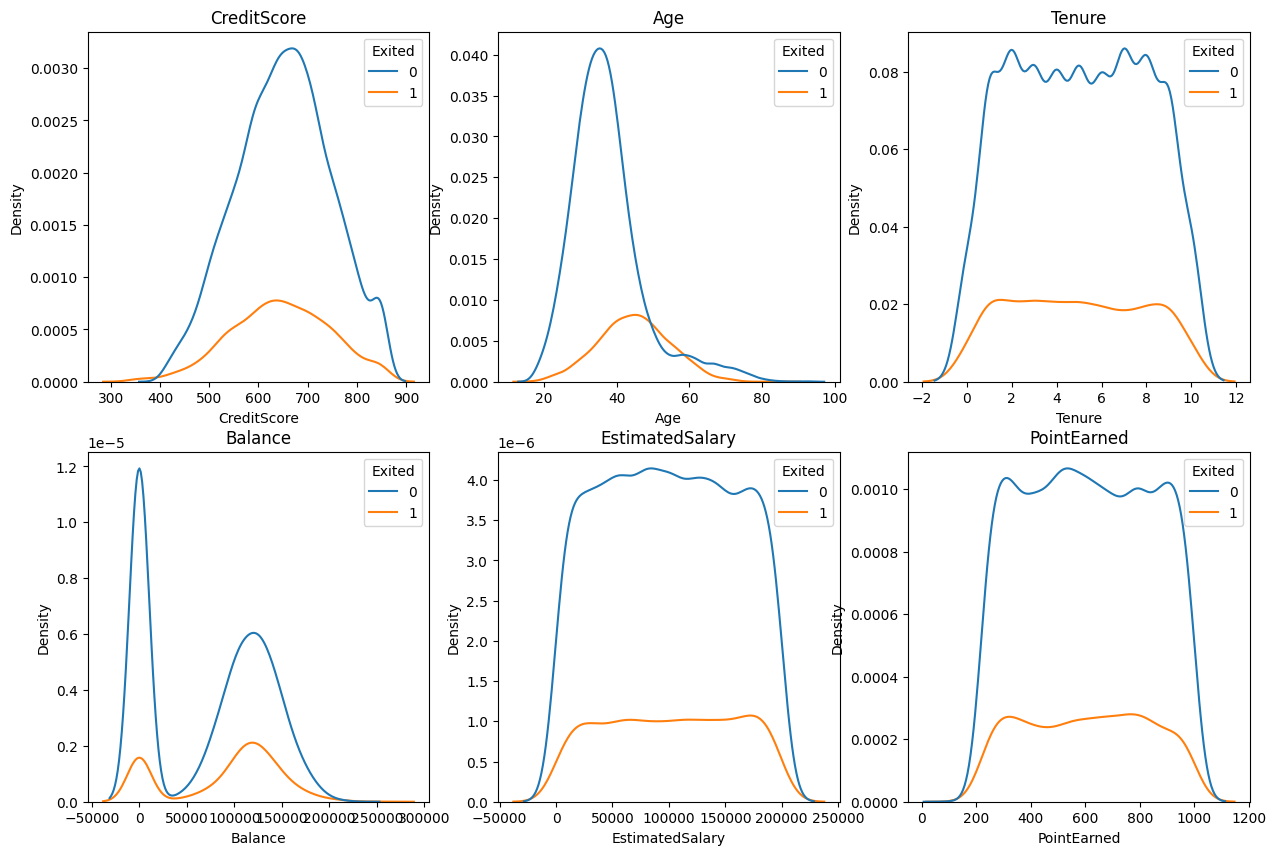

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'PointEarned']

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Exited', ax=ax)
    ax.set_title(col)

<Axes: >

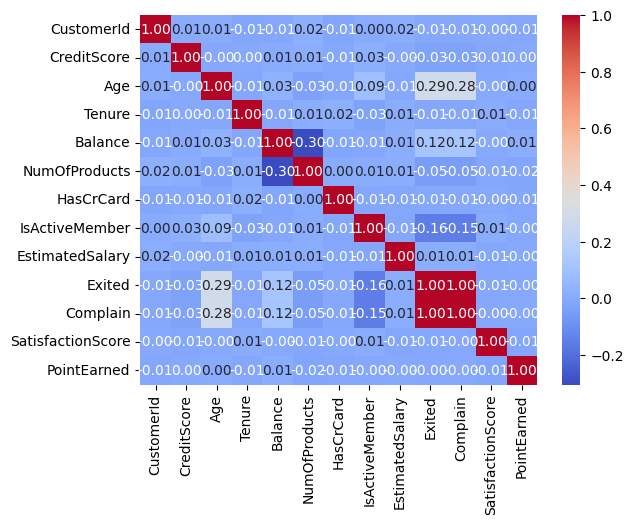

In [45]:
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')

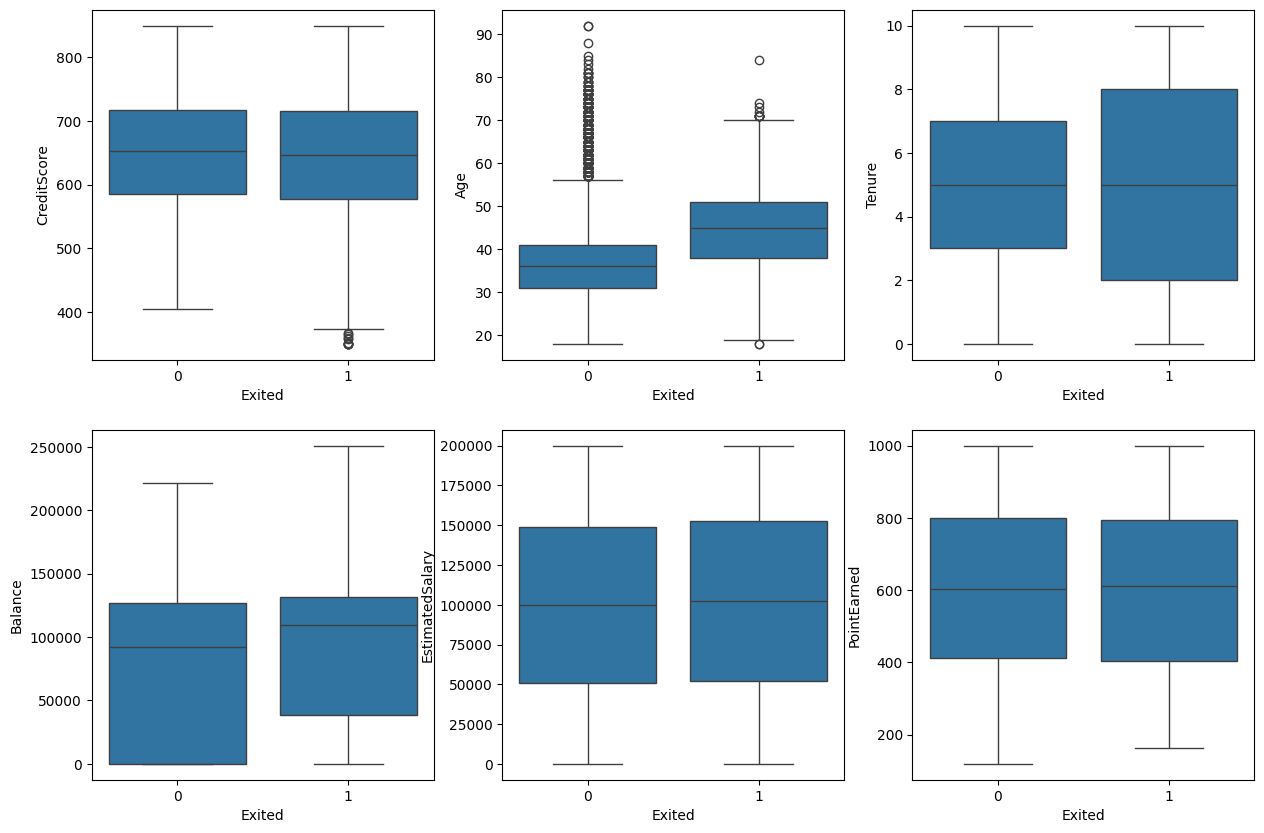

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x='Exited', y=col, ax=ax)

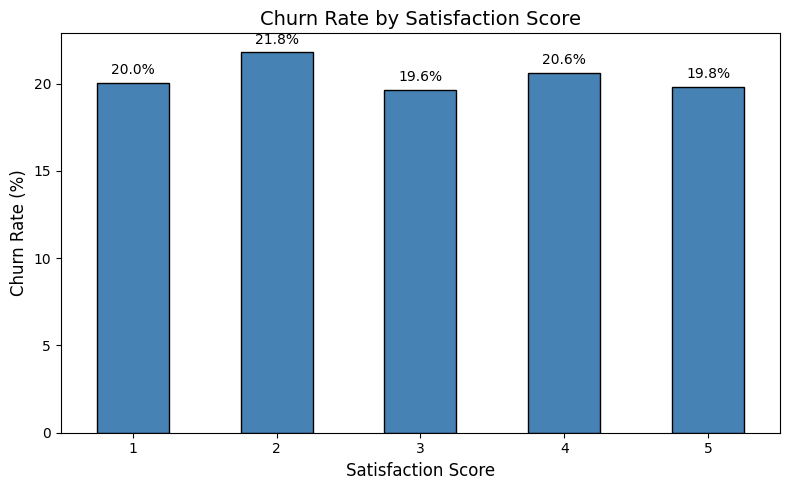

In [48]:
churn_by_satisfaction = df.groupby('SatisfactionScore')['Exited'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
churn_by_satisfaction.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

ax.set_title('Churn Rate by Satisfaction Score', fontsize=14)
ax.set_xlabel('Satisfaction Score', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(churn_by_satisfaction):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

tomorrow: interpret the graphs and make a plan in terms of managing the categorical variables to be able to write the preprocessing.py file

Set customerid as index, remove Surname as it won't be useful in predicting customer churn, and change the other categorical variable to be able to be processed numerically eg OneHotEncoding